# 📰 Fake News Detection — 17-Model NLP & ML/DL Benchmark
### Dataset: 105,375 News Articles | Sample: 15,000 (SK) / 12,000 (DL)

> **No ground-truth labels exist**, so we generate credibility labels via a 9-signal heuristic scoring system, then benchmark 17 models spanning classical ML and modern deep learning.

---

## 🧭 Model List

| # | Model | Type | Feature Input |
|---|-------|------|--------------|
| 1 | Logistic Regression | Linear | TF-IDF |
| 2 | Naive Bayes | Probabilistic | TF-IDF |
| 3 | SVM (LinearSVC) | Linear | TF-IDF |
| 4 | Random Forest | Ensemble (Bagging) | TF-IDF |
| 5 | Extra Trees | Ensemble (Randomized) | TF-IDF |
| 6 | Gradient Boosting | Ensemble (Boosting) | TF-IDF |
| 7 | XGBoost | Gradient Boosting | TF-IDF |
| 8 | LightGBM | Gradient Boosting | TF-IDF |
| 9 | AdaBoost | Ensemble (Boosting) | TF-IDF |
| 10 | Ridge Classifier | Linear | TF-IDF |
| 11 | TextCNN | Deep Learning | Sequences |
| 12 | LSTM | Deep Learning (RNN) | Sequences |
| 13 | Bidirectional LSTM | Deep Learning (RNN) | Sequences |
| 14 | GRU | Deep Learning (RNN) | Sequences |
| 15 | Bidirectional GRU | Deep Learning (RNN) | Sequences |
| 16 | CNN-LSTM Hybrid | Deep Learning (Hybrid) | Sequences |
| 17 | Deep MLP (Word2Vec) | Deep Learning (MLP) | Word2Vec |

---

## 📊 Metrics Computed
`Accuracy` · `Precision` · `Recall` · `F1-Score` · `ROC-AUC` · `RMSE` · `MSE` · `MAE` · `R²` · `MAPE`


## 1. Imports & Setup

In [4]:
!pip install gensim

In [5]:
import warnings; warnings.filterwarnings("ignore")
import os; os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np, pandas as pd, re, gc, time
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, AdaBoostClassifier)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc)
import xgboost as xgb
import lightgbm as lgb

# ── Deep Learning
import tensorflow as tf; tf.get_logger().setLevel("ERROR")
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Dense, Dropout, Conv1D,
    MaxPooling1D, GlobalMaxPooling1D, Bidirectional, Input, concatenate)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# ── Word2Vec
from gensim.models import Word2Vec

print(f"TensorFlow: {tf.__version__} | XGBoost: {xgb.__version__} | LightGBM: {lgb.__version__}")
print("All libraries loaded successfully!")

TensorFlow: 2.19.0 | XGBoost: 3.2.0 | LightGBM: 4.6.0
All libraries loaded successfully!


## 2. Load & Explore Data

In [6]:
COLS = ["source_name","author","title","description","url","full_content","category"]
#df = pd.read_csv("data.csv", usecols=COLS, low_memory=False)
df = pd.read_csv("/content/data.csv.zip", usecols=COLS, low_memory=False, compression='zip')
print(f"Full dataset: {len(df):,} rows × {len(COLS)} columns")
df_sample = df.sample(n=15_000, random_state=42).reset_index(drop=True)
df_sample["full_content"] = df_sample["full_content"].fillna("").str[:600]
print(f"Working sample: {len(df_sample):,} rows")
print(f"\nTop 10 categories:\n{df_sample['category'].value_counts().head(10).to_string()}")
print(f"\nMissing values:\n{df_sample.isnull().sum().to_string()}")

Full dataset: 105,375 rows × 7 columns
Working sample: 15,000 rows

Top 10 categories:
category
Stock          572
Real estate    363
Health         342
Technology     340
Finance        326
Canada         307
Education      267
News           263
COVID          260
Jobs           246

Missing values:
source_name        0
author          1195
title              7
description       57
url                0
category           5
full_content       0


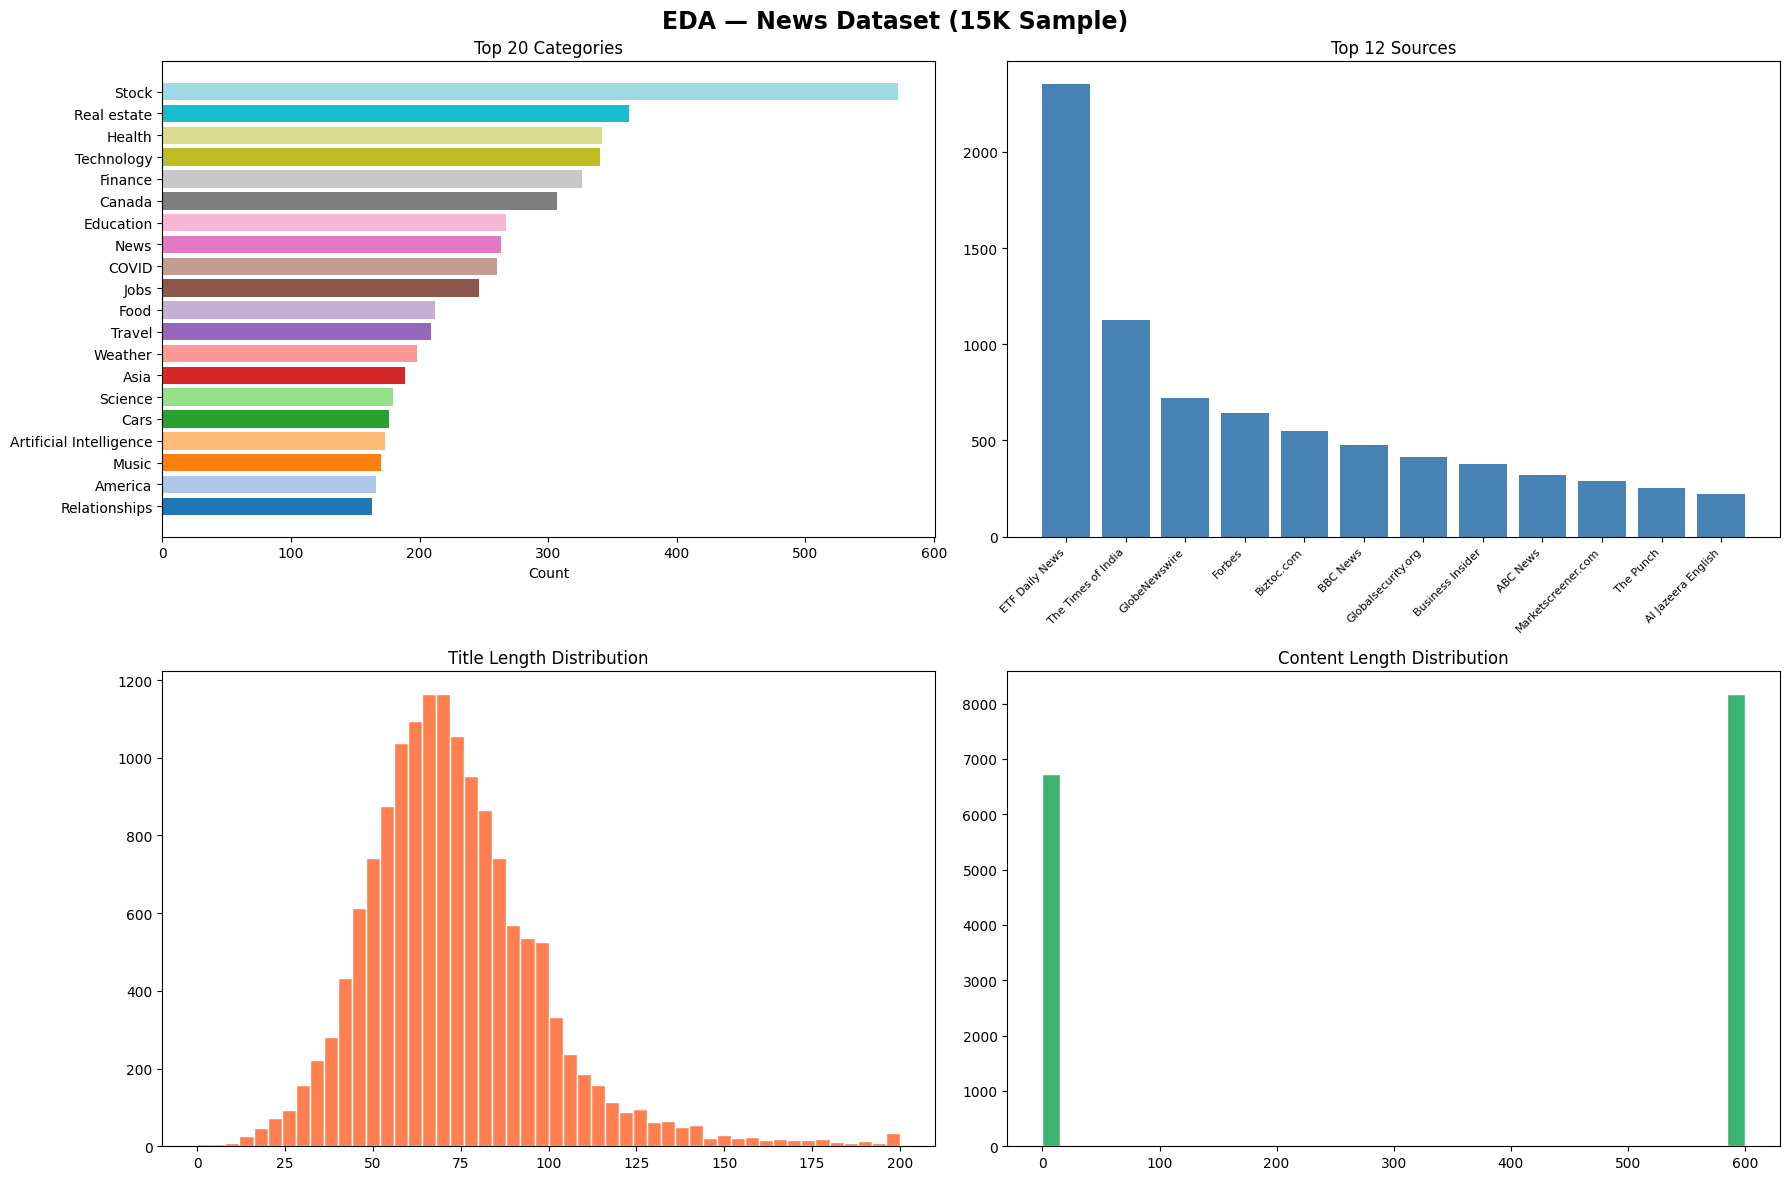

In [7]:
df_sample['title_len']   = df_sample['title'].fillna("").apply(len)
df_sample['content_len'] = df_sample['full_content'].apply(len)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("EDA — News Dataset (15K Sample)", fontsize=17, fontweight="bold")
top_cats = df_sample['category'].value_counts().head(20)
axes[0,0].barh(top_cats.index[::-1], top_cats.values[::-1], color=plt.cm.tab20.colors[:20])
axes[0,0].set_title("Top 20 Categories"); axes[0,0].set_xlabel("Count")
top_src = df_sample['source_name'].value_counts().head(12)
axes[0,1].bar(range(len(top_src)), top_src.values, color="steelblue")
axes[0,1].set_xticks(range(len(top_src))); axes[0,1].set_xticklabels(top_src.index, rotation=45, ha="right", fontsize=8)
axes[0,1].set_title("Top 12 Sources")
axes[1,0].hist(df_sample['title_len'].clip(0,200), bins=50, color="coral", edgecolor="w")
axes[1,0].set_title("Title Length Distribution")
axes[1,1].hist(df_sample['content_len'].clip(0,700), bins=40, color="mediumseagreen", edgecolor="w")
axes[1,1].set_title("Content Length Distribution")
plt.tight_layout(); plt.show()

## 3. Heuristic Credibility Label Generation

| Signal | Rule | Points |
|--------|------|--------|
| Reputable source | Matched against 40+ known outlets | **+3** |
| ALL-CAPS headline | Cap ratio > 45% | **-2** |
| Excessive punctuation | ≥2 `!` or `?` in title | **-1** |
| Clickbait phrases | Pattern matches in title | **-1 each** (max -3) |
| Content length | > 400 chars → +2, > 150 → +1 | **+1/+2** |
| Author byline | Present | **+1** |
| HTTPS URL | Present | **+1** |
| Trusted TLD | .com/.org/.gov/.edu | **+1** |
| Fake TLD | .xyz/.click/.bid etc. | **-2** |

→ **35th percentile threshold**: articles below = FAKE(0), above = REAL(1)


In [8]:
REPUTABLE = {"reuters","associated press","bbc","guardian","npr","new york times",
    "washington post","bloomberg","cnn","nbc","cbs","abc","wall street journal",
    "financial times","economist","time","forbes","usa today","los angeles times",
    "chicago tribune","cnbc","al jazeera","deutsche welle","france 24","independent",
    "telegraph","sky news","politico","axios","propublica","national geographic",
    "scientific american","nature","techcrunch","wired","ars technica",
    "international business times","bbc news","ap news"}
CLICKBAIT = [r"you won't believe",r"shocking",r"miracle",r"cure",r"explosive",
             r"urgent",r"conspiracy",r"government hides",r"covered up",
             r"doctors hate",r"one weird trick",r"secret"]
FAKE_TLDS  = [".xyz",".info",".biz",".click",".top",".win",".loan",".download",
              ".racing",".stream",".bid",".webcam",".gq",".ml",".cf",".tk"]

def score_cred(row):
    s = 0
    if any(r in str(row.get("source_name","") or "").lower() for r in REPUTABLE): s += 3
    title = str(row.get("title","") or "")
    if sum(c.isupper() for c in title)/max(len(title),1) > 0.45: s -= 2
    if (title.count("!") + title.count("?")) >= 2: s -= 1
    s -= min(sum(1 for p in CLICKBAIT if re.search(p, title.lower())), 3)
    clen = len(str(row.get("full_content","") or ""))
    s += 2 if clen > 400 else (1 if clen > 150 else 0)
    if str(row.get("author","") or "") not in ("","nan","None"): s += 1
    url = str(row.get("url","") or "").lower()
    if any(t in url for t in FAKE_TLDS): s -= 2
    if "https://" in url: s += 1
    if re.search(r"\.(com|org|gov|edu|net)/", url): s += 1
    return s

df_sample["cred_score"] = df_sample.apply(score_cred, axis=1)
threshold = df_sample["cred_score"].quantile(0.35)
df_sample["label"] = (df_sample["cred_score"] >= threshold).astype(int)
vc = df_sample["label"].value_counts()
print(f"Threshold={threshold} | REAL={vc.get(1,0):,} | FAKE={vc.get(0,0):,} ({vc.get(0,0)/len(df_sample)*100:.1f}% fake)")

Threshold=3.0 | REAL=13,779 | FAKE=1,221 (8.1% fake)


## 4. Text Cleaning & Feature Engineering
### 4a. TF-IDF (for ML models)

In [9]:
def clean_text(text):
    text = re.sub(r"http\S+", " ", str(text or ""))
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip().lower()

df_sample["text"] = (df_sample["title"].fillna("") + " " +
                     df_sample["description"].fillna("") + " " +
                     df_sample["full_content"]).apply(clean_text)
df_sample = df_sample[df_sample["text"].str.len() > 30].reset_index(drop=True)
y = df_sample["label"].values

# TF-IDF: 15K features, unigrams + bigrams
tfidf = TfidfVectorizer(max_features=15_000, ngram_range=(1,2),
                        sublinear_tf=True, min_df=3, max_df=0.90)
X_tfidf = tfidf.fit_transform(df_sample["text"])
feat_names = tfidf.get_feature_names_out()
print(f"TF-IDF matrix: {X_tfidf.shape}")

Xtr_tf, Xte_tf, ytr, yte = train_test_split(X_tfidf, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train: {Xtr_tf.shape[0]:,} | Test: {Xte_tf.shape[0]:,}")

TF-IDF matrix: (14830, 15000)
Train: 11,864 | Test: 2,966


### 4b. Keras Tokenizer + Word2Vec (for DL models)

In [10]:
# Keras sequences
MAX_VOCAB, MAX_LEN, EMBED_DIM, W2V_DIM = 12_000, 100, 32, 64
tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok.fit_on_texts(df_sample["text"])
X_seq = pad_sequences(tok.texts_to_sequences(df_sample["text"]),
                      maxlen=MAX_LEN, padding="post", truncating="post")
Xtr_seq, Xte_seq, _, _ = train_test_split(X_seq, y, test_size=0.20, random_state=42, stratify=y)
print(f"Sequence matrix: {X_seq.shape}")

# Word2Vec embeddings
sentences = [t.split() for t in df_sample["text"]]
w2v = Word2Vec(sentences, vector_size=W2V_DIM, window=5, min_count=2, workers=4, epochs=5, seed=42)
def to_w2v(text):
    vecs = [w2v.wv[w] for w in text.split() if w in w2v.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(W2V_DIM)
X_w2v = np.array([to_w2v(t) for t in df_sample["text"]])
Xtr_w2v, Xte_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.20, random_state=42, stratify=y)
print(f"Word2Vec matrix: {X_w2v.shape}")

Sequence matrix: (14830, 100)
Word2Vec matrix: (14830, 64)


## 5. Train 10 ML Models (TF-IDF Features)

In [11]:
def compute_metrics(yt, yp, yprob=None):
    acc  = accuracy_score(yt, yp)
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    try: roc = roc_auc_score(yt, yprob if yprob is not None else yp)
    except: roc = float("nan")
    mse  = mean_squared_error(yt, yp); rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yt, yp); r2 = r2_score(yt, yp)
    mask = yt != 0
    mape = np.mean(np.abs((yt[mask]-yp[mask])/yt[mask]))*100 if mask.sum()>0 else float("nan")
    return dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1, ROC_AUC=roc,
                RMSE=rmse, MSE=mse, MAE=mae, R2=r2, MAPE=mape)

SK_MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=500, C=1.0, solver="saga", n_jobs=-1, random_state=42),
    "Naive Bayes":         MultinomialNB(alpha=0.1),
    "SVM (LinearSVC)":     LinearSVC(C=0.5, max_iter=2000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "XGBoost":             xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                                              tree_method="hist", n_jobs=-1, random_state=42, verbosity=0, eval_metric="logloss"),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=8,
                                               num_leaves=63, n_jobs=-1, random_state=42, verbose=-1),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42),
    "Ridge Classifier":    RidgeClassifier(alpha=1.0),
}

results = {}; preds_d = {}; probs_d = {}; cms = {}; feat_imps = {}
print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
print("-"*60)
for name, model in SK_MODELS.items():
    model.fit(Xtr_tf, ytr)
    yp = model.predict(Xte_tf)
    if hasattr(model,"predict_proba"): yprob=model.predict_proba(Xte_tf)[:,1]
    elif hasattr(model,"decision_function"):
        d=model.decision_function(Xte_tf); yprob=(d-d.min())/(d.max()-d.min()+1e-9)
    else: yprob=yp.astype(float)
    m = compute_metrics(yte, yp, yprob)
    results[name]=m; preds_d[name]=yp; probs_d[name]=yprob; cms[name]=confusion_matrix(yte,yp)
    if hasattr(model,"feature_importances_"): feat_imps[name]=model.feature_importances_
    print(f"{name:<22} {m['Accuracy']:>7.4f} {m['Precision']:>7.4f} {m['Recall']:>7.4f} {m['F1']:>7.4f} {m['ROC_AUC']:>7.4f}")
    gc.collect()

Model                      Acc    Prec     Rec      F1     AUC
------------------------------------------------------------
Logistic Regression     0.9278  0.9277  1.0000  0.9625  0.8488
Naive Bayes             0.9309  0.9320  0.9982  0.9639  0.7628
SVM (LinearSVC)         0.9322  0.9344  0.9967  0.9646  0.8203
Random Forest           0.9268  0.9267  1.0000  0.9620  0.8490
Extra Trees             0.9268  0.9267  1.0000  0.9620  0.8397
Gradient Boosting       0.9349  0.9367  0.9971  0.9659  0.8360
XGBoost                 0.9322  0.9335  0.9978  0.9646  0.8635
LightGBM                0.9319  0.9326  0.9985  0.9645  0.8681
AdaBoost                0.9265  0.9273  0.9989  0.9618  0.8037
Ridge Classifier        0.9326  0.9336  0.9982  0.9648  0.7924


## 6. Train 7 Deep Learning Models

In [12]:
EPOCHS, BATCH = 4, 128
es = EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)

def run_keras(model, name, X_train, X_val, y_train, y_val):
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=EPOCHS, batch_size=BATCH, callbacks=[es], verbose=0)
    yprob = model.predict(X_val, verbose=0).ravel()
    yp = (yprob >= 0.5).astype(int)
    m = compute_metrics(y_val, yp, yprob)
    results[name]=m; preds_d[name]=yp; probs_d[name]=yprob; cms[name]=confusion_matrix(y_val,yp)
    print(f"{name:<22} {m['Accuracy']:>7.4f} {m['Precision']:>7.4f} {m['Recall']:>7.4f} {m['F1']:>7.4f} {m['ROC_AUC']:>7.4f}")
    tf.keras.backend.clear_session(); gc.collect()

print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
print("-"*60)

# TextCNN
inp = Input(shape=(MAX_LEN,)); emb = Embedding(MAX_VOCAB, EMBED_DIM)(inp)
convs = [GlobalMaxPooling1D()(Conv1D(64, fs, activation="relu")(emb)) for fs in [2,3,4]]
out = Dense(1, activation="sigmoid")(Dense(64, activation="relu")(Dropout(0.3)(concatenate(convs))))
run_keras(Model(inp,out), "TextCNN", Xtr_seq, Xte_seq, ytr, yte)

run_keras(Sequential([Embedding(MAX_VOCAB,EMBED_DIM,input_length=MAX_LEN),LSTM(32,dropout=0.2),Dense(16,activation="relu"),Dropout(0.3),Dense(1,activation="sigmoid")]), "LSTM", Xtr_seq, Xte_seq, ytr, yte)
run_keras(Sequential([Embedding(MAX_VOCAB,EMBED_DIM,input_length=MAX_LEN),Bidirectional(LSTM(32,dropout=0.2)),Dense(16,activation="relu"),Dropout(0.3),Dense(1,activation="sigmoid")]), "BiLSTM", Xtr_seq, Xte_seq, ytr, yte)
run_keras(Sequential([Embedding(MAX_VOCAB,EMBED_DIM,input_length=MAX_LEN),GRU(32,dropout=0.2),Dense(16,activation="relu"),Dropout(0.3),Dense(1,activation="sigmoid")]), "GRU", Xtr_seq, Xte_seq, ytr, yte)
run_keras(Sequential([Embedding(MAX_VOCAB,EMBED_DIM,input_length=MAX_LEN),Bidirectional(GRU(32,dropout=0.2)),Dense(16,activation="relu"),Dropout(0.3),Dense(1,activation="sigmoid")]), "BiGRU", Xtr_seq, Xte_seq, ytr, yte)
run_keras(Sequential([Embedding(MAX_VOCAB,EMBED_DIM,input_length=MAX_LEN),Conv1D(64,3,activation="relu"),MaxPooling1D(2),LSTM(32,dropout=0.2),Dense(16,activation="relu"),Dropout(0.3),Dense(1,activation="sigmoid")]), "CNN-LSTM", Xtr_seq, Xte_seq, ytr, yte)
run_keras(Sequential([Dense(128,activation="relu",input_shape=(W2V_DIM,)),Dropout(0.4),Dense(64,activation="relu"),Dropout(0.3),Dense(32,activation="relu"),Dense(1,activation="sigmoid")]), "Deep MLP (W2V)", Xtr_w2v, Xte_w2v, ytr, yte)

Model                      Acc    Prec     Rec      F1     AUC
------------------------------------------------------------
TextCNN                 0.9255  0.9255  1.0000  0.9613  0.7958
LSTM                    0.9255  0.9255  1.0000  0.9613  0.8068
BiLSTM                  0.9268  0.9279  0.9985  0.9619  0.8628
GRU                     0.9255  0.9255  1.0000  0.9613  0.8022
BiGRU                   0.9319  0.9383  0.9916  0.9642  0.8693
CNN-LSTM                0.9255  0.9255  1.0000  0.9613  0.8032
Deep MLP (W2V)          0.9255  0.9255  1.0000  0.9613  0.6942


## 7. Comprehensive Metrics Table

In [13]:
metrics_df = pd.DataFrame(results).T
metrics_df.columns = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC",
                       "RMSE","MSE","MAE","R²","MAPE(%)"]
metrics_df = metrics_df.round(4); metrics_df.index.name = "Model"
BEST = metrics_df["F1-Score"].idxmax()
print(metrics_df.to_string())
print(f"\n🏆 BEST MODEL (F1-Score): {BEST}  →  {metrics_df.loc[BEST,'F1-Score']:.4f}")
metrics_df.to_csv("model_metrics.csv")

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC    RMSE     MSE     MAE      R²  MAPE(%)
Model                                                                                                       
Logistic Regression    0.9278     0.9277  1.0000    0.9625   0.8488  0.2686  0.0722  0.0722 -0.0463   0.0000
Naive Bayes            0.9309     0.9320  0.9982    0.9639   0.7628  0.2629  0.0691  0.0691 -0.0023   0.1821
SVM (LinearSVC)        0.9322     0.9344  0.9967    0.9646   0.8203  0.2603  0.0678  0.0678  0.0173   0.3279
Random Forest          0.9268     0.9267  1.0000    0.9620   0.8490  0.2705  0.0732  0.0732 -0.0610   0.0000
Extra Trees            0.9268     0.9267  1.0000    0.9620   0.8397  0.2705  0.0732  0.0732 -0.0610   0.0000
Gradient Boosting      0.9349     0.9367  0.9971    0.9659   0.8360  0.2551  0.0651  0.0651  0.0564   0.2914
XGBoost                0.9322     0.9335  0.9978    0.9646   0.8635  0.2603  0.0678  0.0678  0.0173   0.2186
LightGBM           

## 8. Heatmaps

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.0)

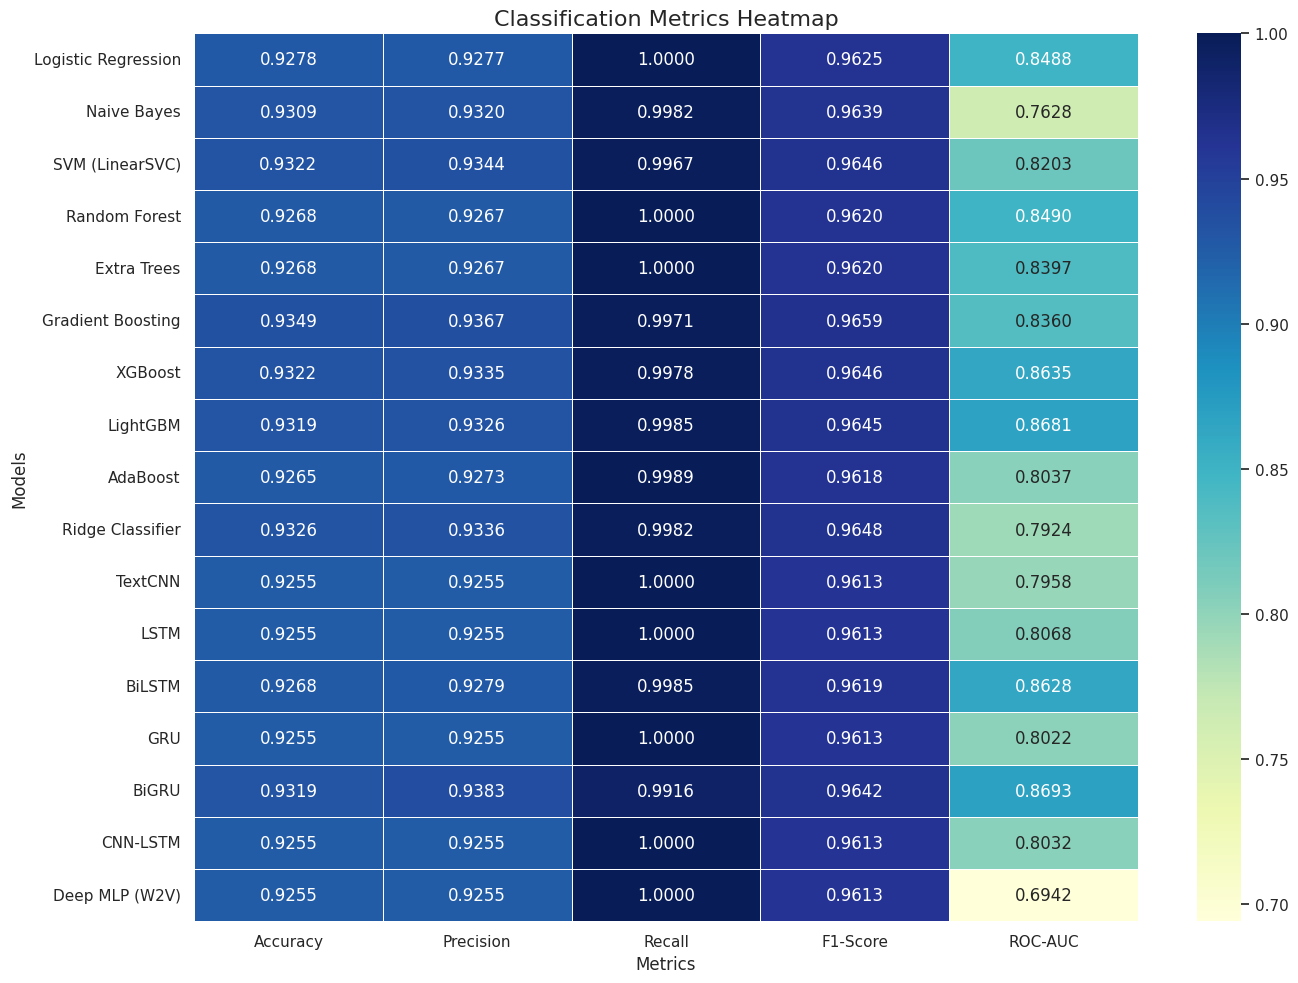

In [15]:
# Classification metrics heatmap
cls_cols = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]

plt.figure(figsize=(14,10))
sns.heatmap(metrics_df[cls_cols],
            annot=True,
            cmap="YlGnBu",
            fmt=".4f",
            linewidths=0.5)

plt.title("Classification Metrics Heatmap", fontsize=16)
plt.ylabel("Models")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

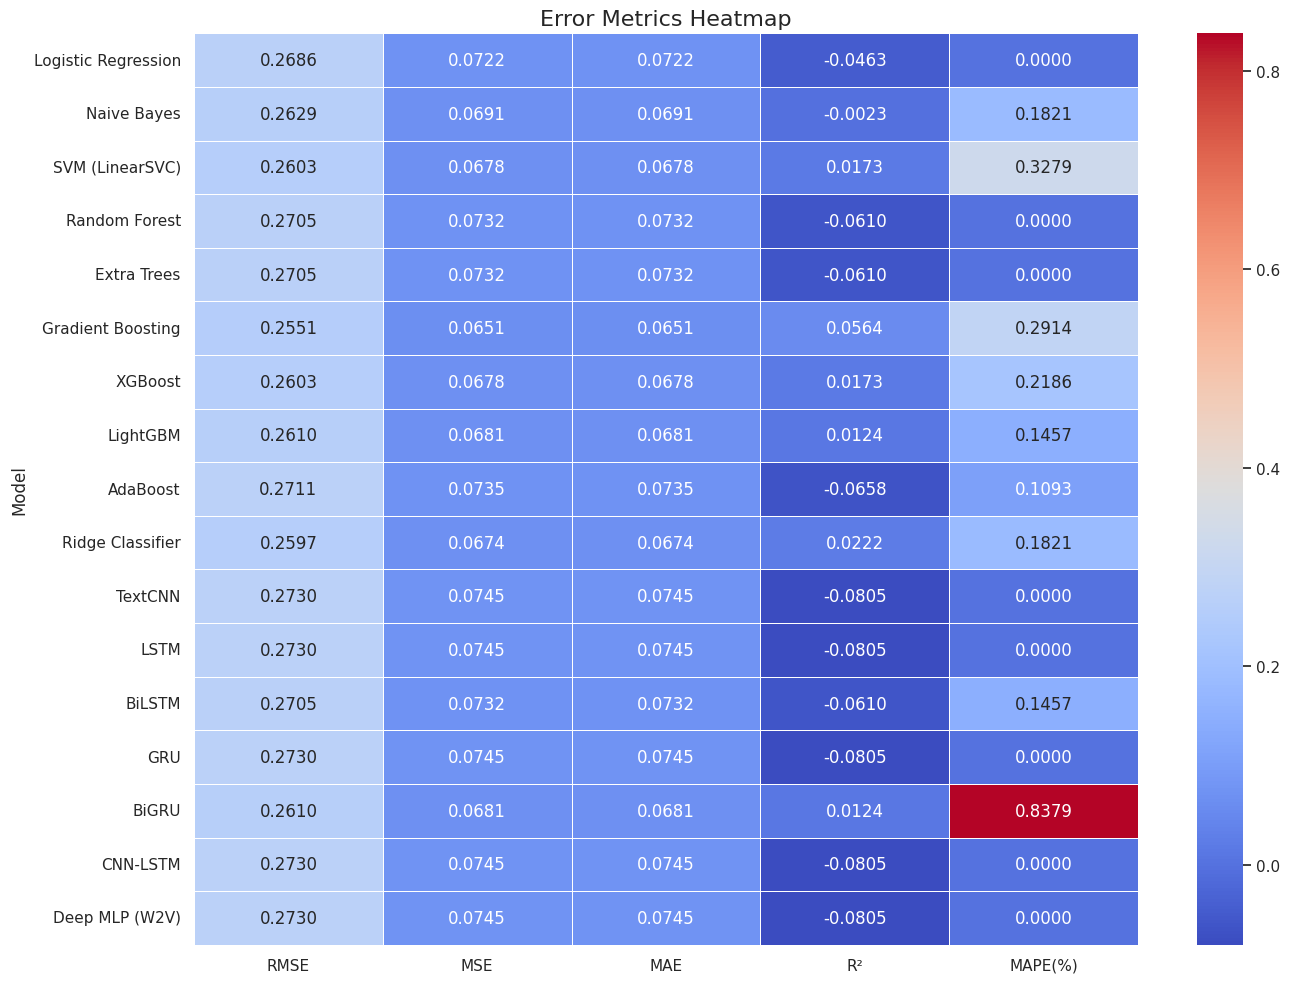

In [16]:
#Error Metrics Heatmap (RMSE, MSE, MAE, R², MAPE)
err_cols = ["RMSE","MSE","MAE","R²","MAPE(%)"]

plt.figure(figsize=(14,10))
sns.heatmap(metrics_df[err_cols],
            annot=True,
            cmap="coolwarm",
            fmt=".4f",
            linewidths=0.5)

plt.title("Error Metrics Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

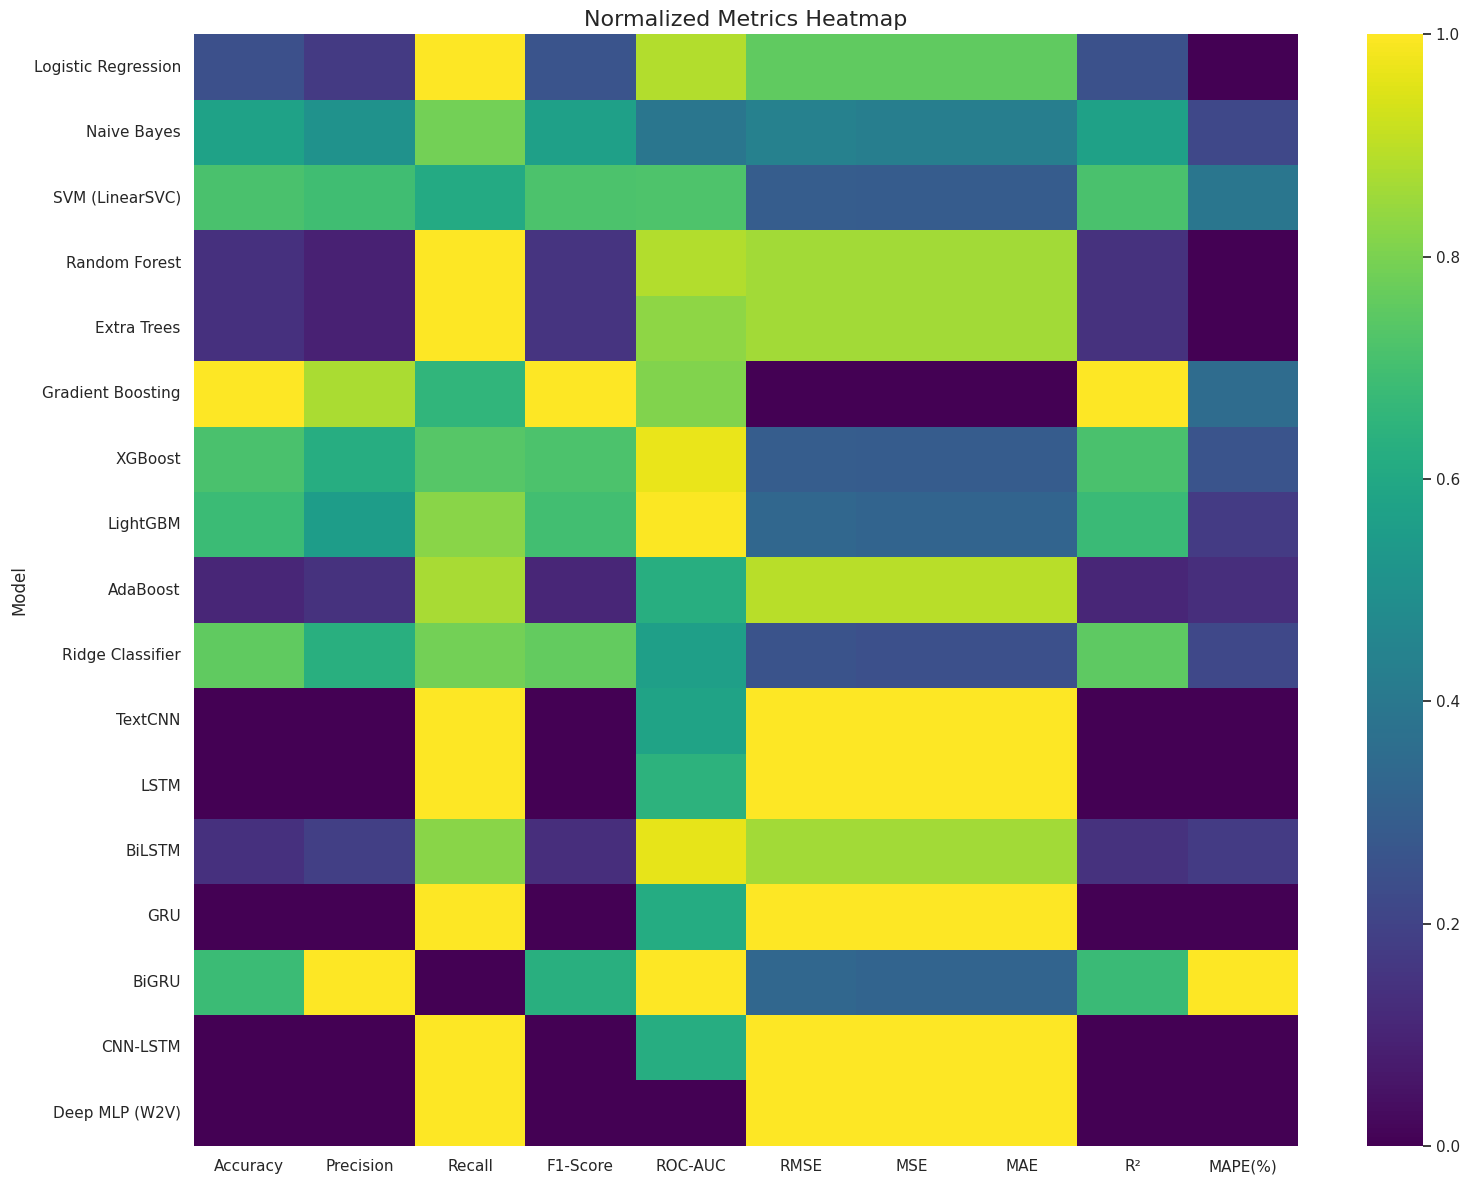

In [17]:
# Normalized full heatmap
normalized_df = (metrics_df - metrics_df.min()) / (metrics_df.max() - metrics_df.min())

plt.figure(figsize=(16,12))
sns.heatmap(normalized_df,
            cmap="viridis",
            annot=False)

plt.title("Normalized Metrics Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## 9. Confusion Matrices — All 17 Models

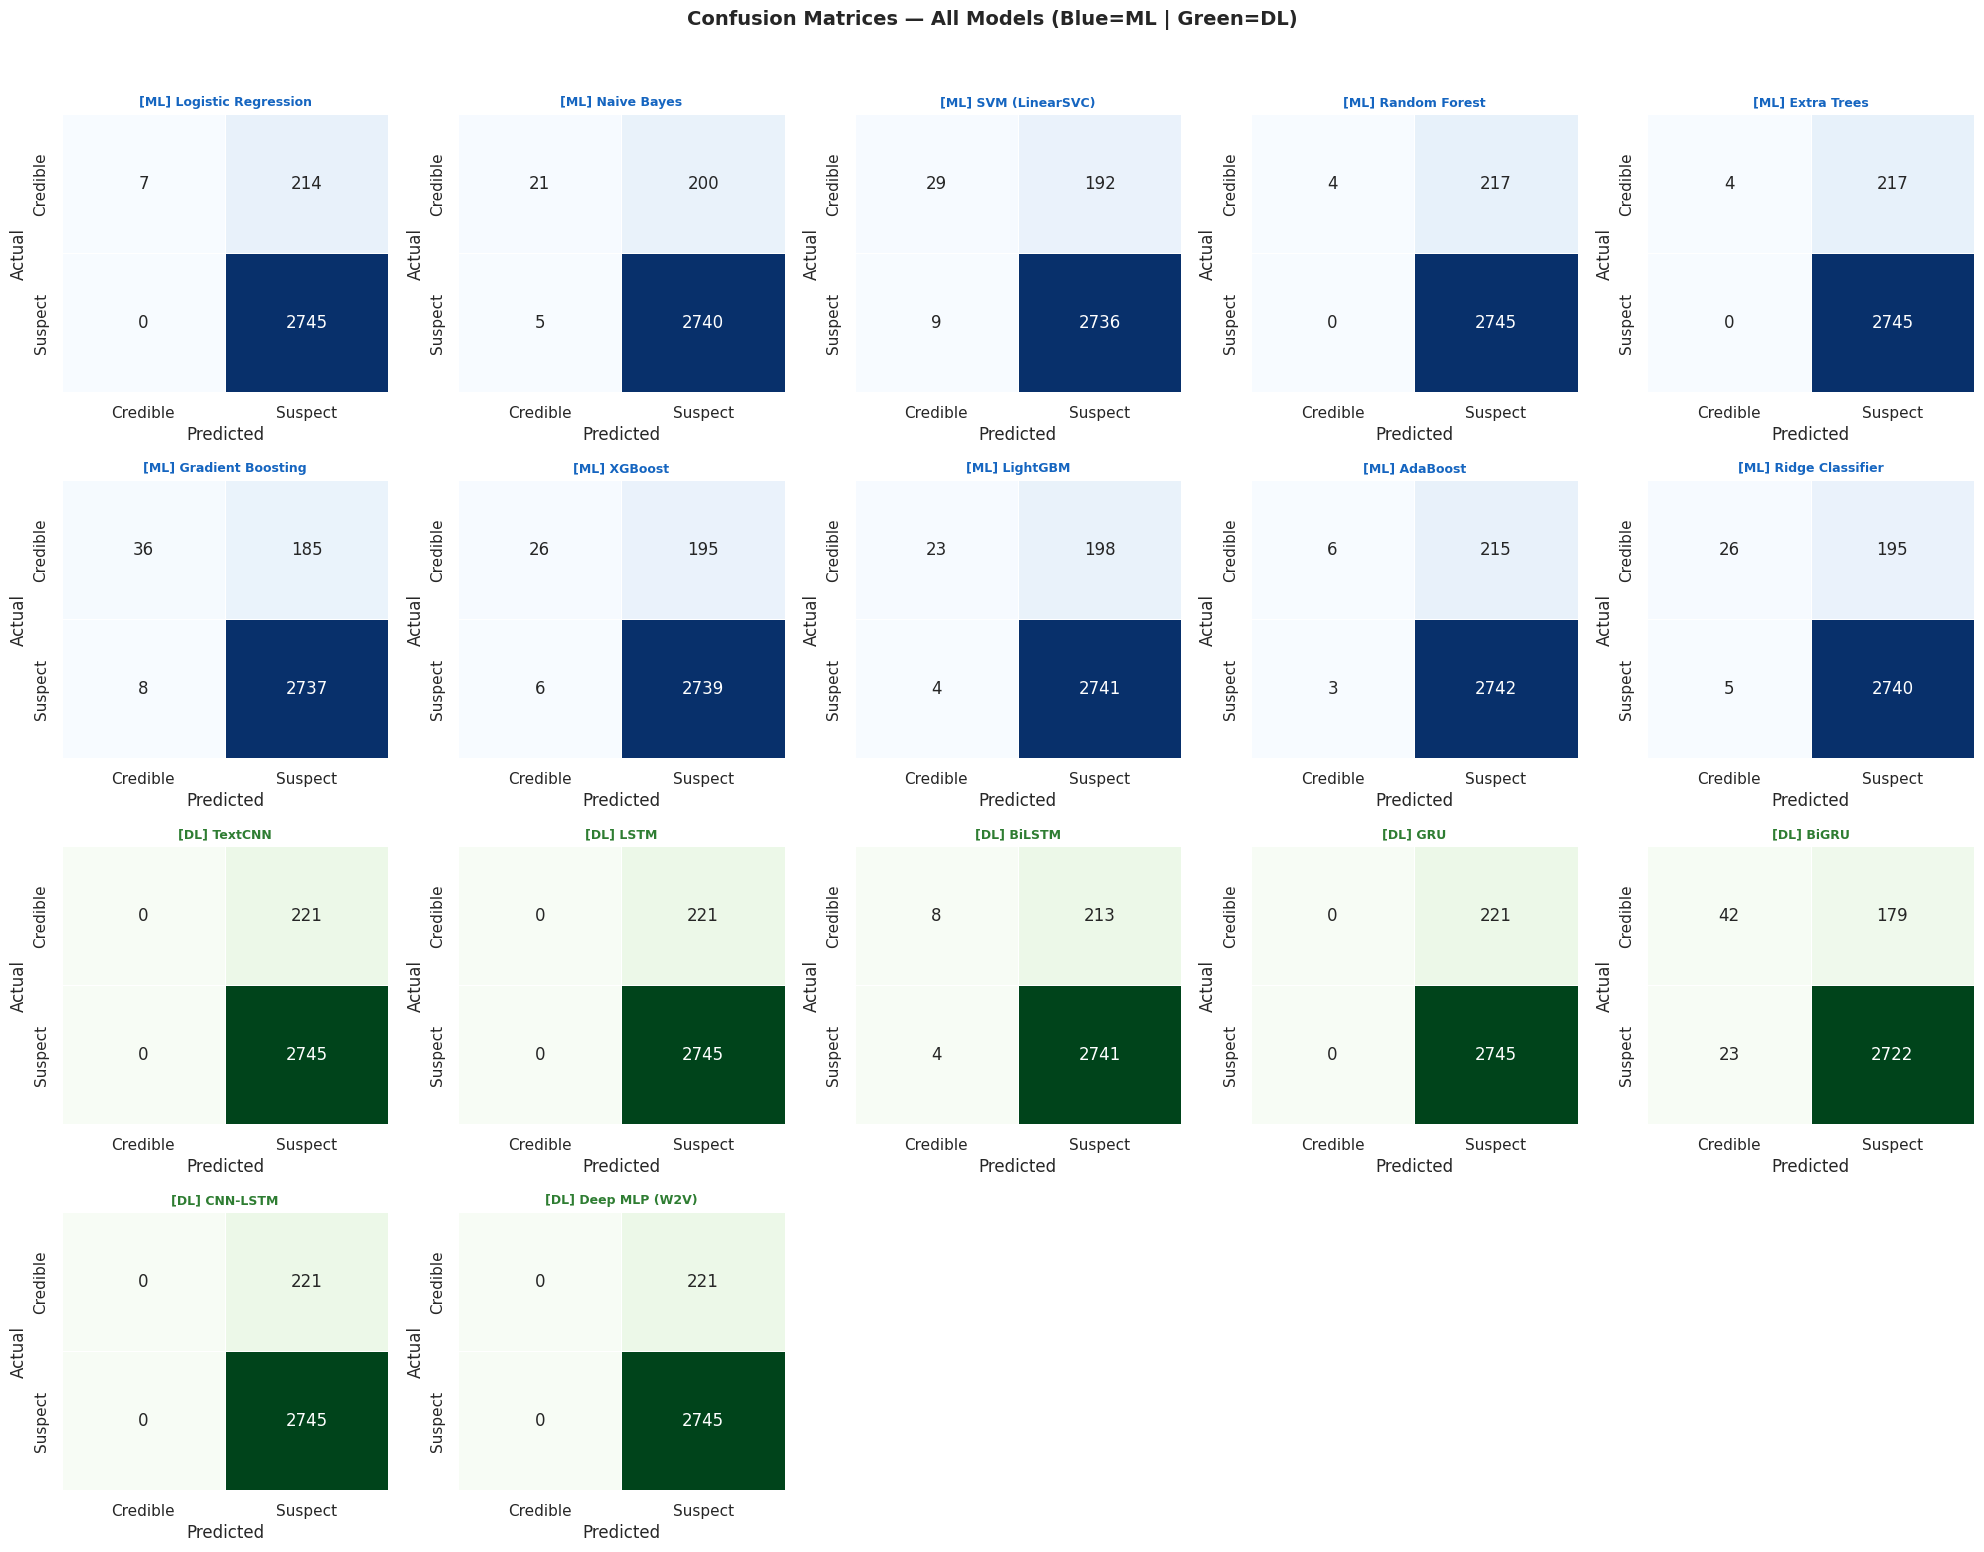

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

MODEL_NAMES = list(cms.keys())

DL_NAMES = ["TextCNN","LSTM","BiLSTM","GRU","BiGRU","CNN-LSTM","Deep MLP (W2V)"]
ML_NAMES = [m for m in MODEL_NAMES if m not in DL_NAMES]

cols, rows = 5, 4
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.8))
axes = axes.flatten()

labels = ['Credible', 'Suspect']

for i, name in enumerate(MODEL_NAMES):
    cm = np.array(cms[name])
    cmap = 'Blues' if name in ML_NAMES else 'Greens'

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap=cmap,
                ax=axes[i],
                xticklabels=labels,
                yticklabels=labels,
                linewidths=0.5,
                cbar=False)

    axes[i].set_title(
        f"[{'ML' if name in ML_NAMES else 'DL'}] {name}",
        fontsize=9,
        fontweight='bold',
        color='#1565C0' if name in ML_NAMES else '#2E7D32'
    )

    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Confusion Matrices — All Models (Blue=ML | Green=DL)",
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

In [20]:
print(type(results))
print(results.keys())

first_key = list(results.keys())[0]
print(results[first_key])

<class 'dict'>
dict_keys(['Logistic Regression', 'Naive Bayes', 'SVM (LinearSVC)', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'AdaBoost', 'Ridge Classifier', 'TextCNN', 'LSTM', 'BiLSTM', 'GRU', 'BiGRU', 'CNN-LSTM', 'Deep MLP (W2V)'])
{'Accuracy': 0.9278489548213081, 'Precision': 0.9276782696857047, 'Recall': 1.0, 'F1': 0.9624824684431977, 'ROC_AUC': np.float64(0.8488152049386379), 'RMSE': np.float64(0.2686094659141629), 'MSE': 0.07215104517869184, 'MAE': 0.07215104517869184, 'R2': -0.046285718995458414, 'MAPE': np.float64(0.0)}


## 10. AUC-ROC Curves

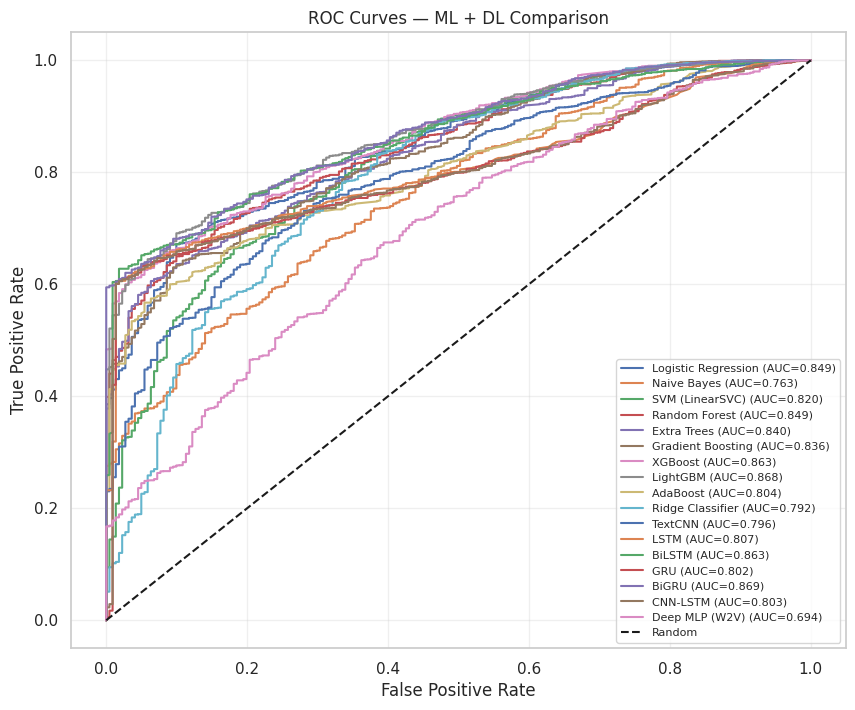

In [23]:
# ROC curves — ML + DL + AUC comparison
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

for name in MODEL_NAMES:
    y_true = yte                    # true labels
    y_prob = probs_d[name]          # predicted probabilities (already stored)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

# Diagonal line for random guessing
plt.plot([0,1],[0,1],'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — ML + DL Comparison")
plt.legend(fontsize=8, loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 11. Extended Analysis

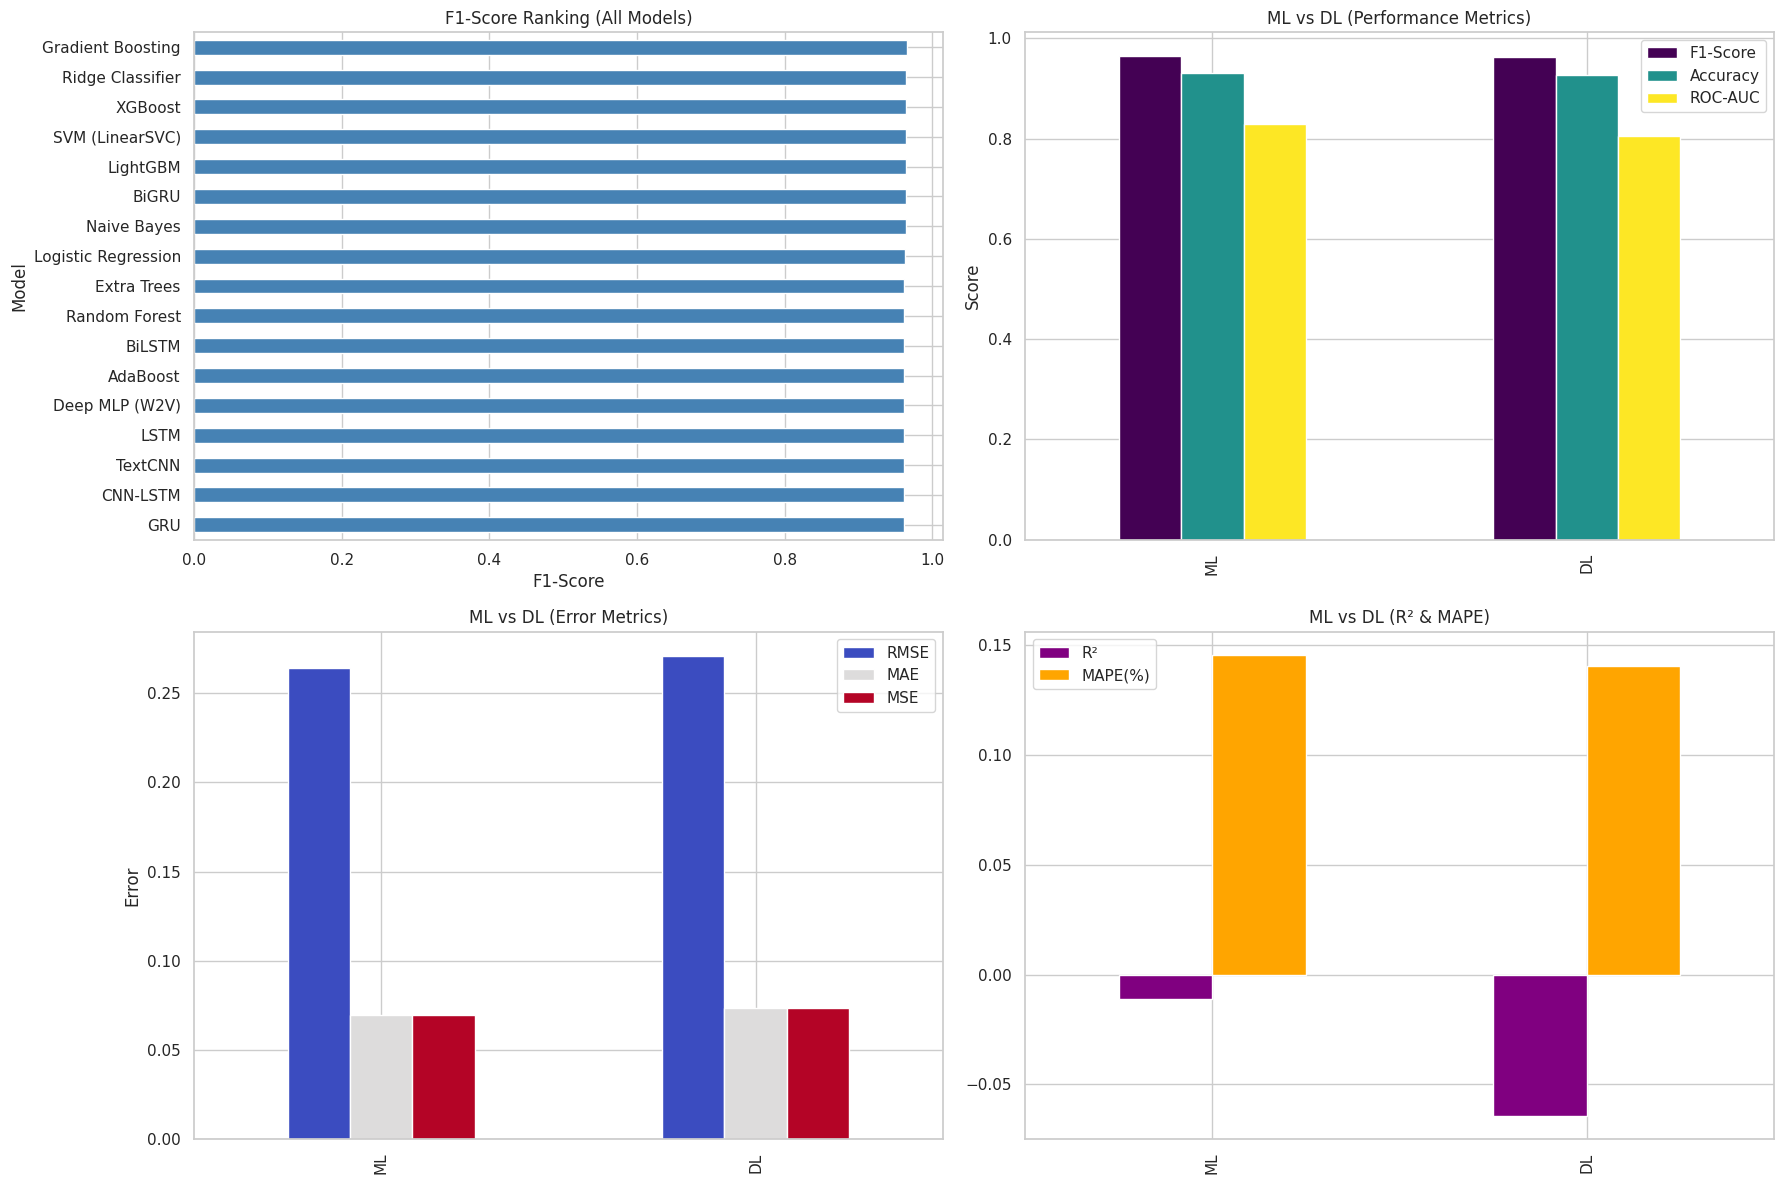

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

'DL / ML model names'
DL_NAMES = ["TextCNN","LSTM","BiLSTM","GRU","BiGRU","CNN-LSTM","Deep MLP (W2V)"]
ML_NAMES = [m for m in metrics_df.index if m not in DL_NAMES]

'Compute averages'
ml_avg = metrics_df.loc[ML_NAMES].mean()
dl_avg = metrics_df.loc[DL_NAMES].mean()
compare_df = pd.DataFrame({"ML": ml_avg, "DL": dl_avg})
fig, axes = plt.subplots(2, 2, figsize=(18,12))

'(1) F1 Ranking (All Models)'
metrics_df.sort_values("F1-Score")["F1-Score"].plot(
    kind="barh", ax=axes[0,0], color="steelblue"
)
axes[0,0].set_title("F1-Score Ranking (All Models)")
axes[0,0].set_xlabel("F1-Score")

'(2) ML vs DL Performance (F1 / Accuracy / ROC-AUC)'
compare_df.loc[["F1-Score","Accuracy","ROC-AUC"]].T.plot(
    kind="bar", ax=axes[0,1], colormap="viridis"
)
axes[0,1].set_title("ML vs DL (Performance Metrics)")
axes[0,1].set_ylabel("Score")

'(3) Error Metrics (RMSE / MAE / MSE)'
compare_df.loc[["RMSE","MAE","MSE"]].T.plot(
    kind="bar", ax=axes[1,0], colormap="coolwarm"
)
axes[1,0].set_title("ML vs DL (Error Metrics)")
axes[1,0].set_ylabel("Error")

'(4) R² & MAPE'
compare_df.loc[["R²","MAPE(%)"]].T.plot(
    kind="bar", ax=axes[1,1], color=["purple","orange"]
)
axes[1,1].set_title("ML vs DL (R² & MAPE)")

plt.tight_layout()
plt.show()

## 12. Architecture Comparison — ML vs DL

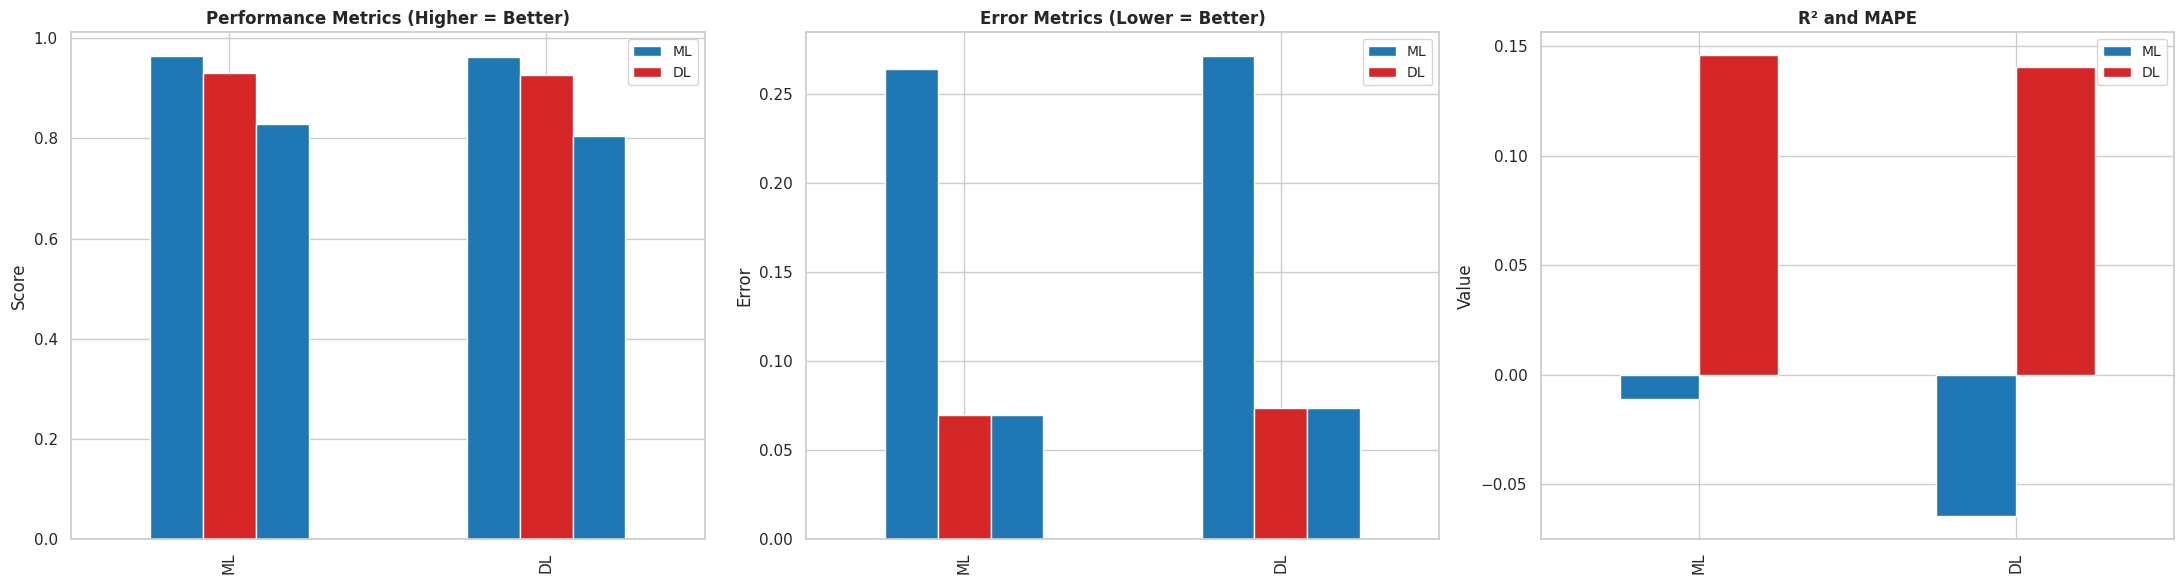

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

'''DL / ML model names'''
DL_NAMES = ["TextCNN","LSTM","BiLSTM","GRU","BiGRU","CNN-LSTM","Deep MLP (W2V)"]
ML_NAMES = [m for m in metrics_df.index if m not in DL_NAMES]

'''Compute averages for ML vs DL'''
ml_avg = metrics_df.loc[ML_NAMES].mean()
dl_avg = metrics_df.loc[DL_NAMES].mean()
compare_df = pd.DataFrame({"ML": ml_avg, "DL": dl_avg})

'''Create figure with 3 subplots'''
fig, axes = plt.subplots(1,3, figsize=(22,6))

colors = ["#1f77b4", "#d62728"]  # ML=blue, DL=red

'''(1) Performance metrics (F1 / Accuracy / ROC-AUC)'''
compare_df.loc[["F1-Score","Accuracy","ROC-AUC"]].T.plot(
    kind="bar", ax=axes[0], color=colors
)
axes[0].set_title("Performance Metrics (Higher = Better)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Score")
axes[0].legend(["ML","DL"], fontsize=10)

'''(2) Error metrics (RMSE / MAE / MSE)'''
compare_df.loc[["RMSE","MAE","MSE"]].T.plot(
    kind="bar", ax=axes[1], color=colors
)
axes[1].set_title("Error Metrics (Lower = Better)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Error")
axes[1].legend(["ML","DL"], fontsize=10)

'''(3) R² and MAPE'''
compare_df.loc[["R²","MAPE(%)"]].T.plot(
    kind="bar", ax=axes[2], color=colors
)
axes[2].set_title("R² and MAPE", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Value")
axes[2].legend(["ML","DL"], fontsize=10)

plt.tight_layout()
plt.show()

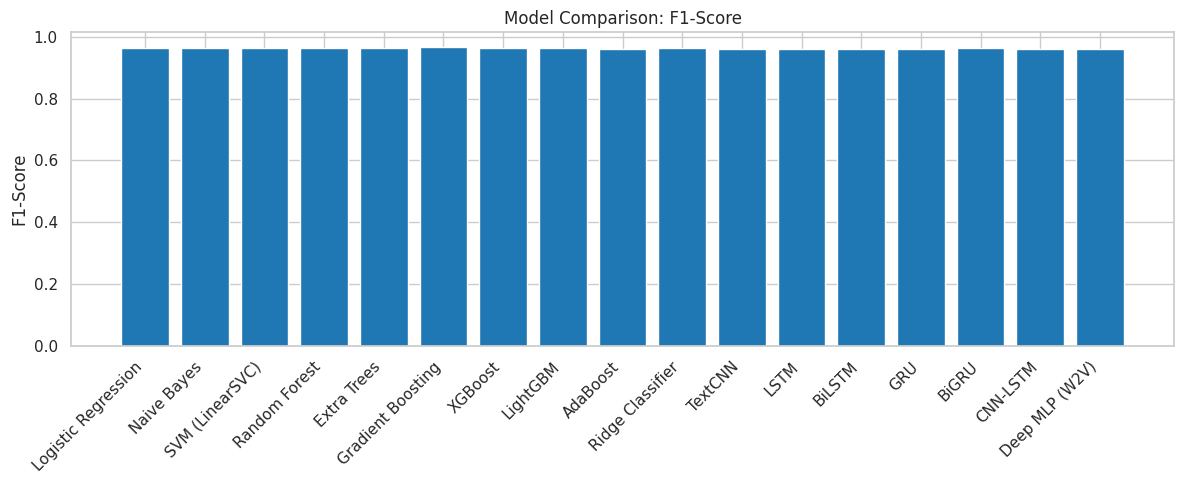

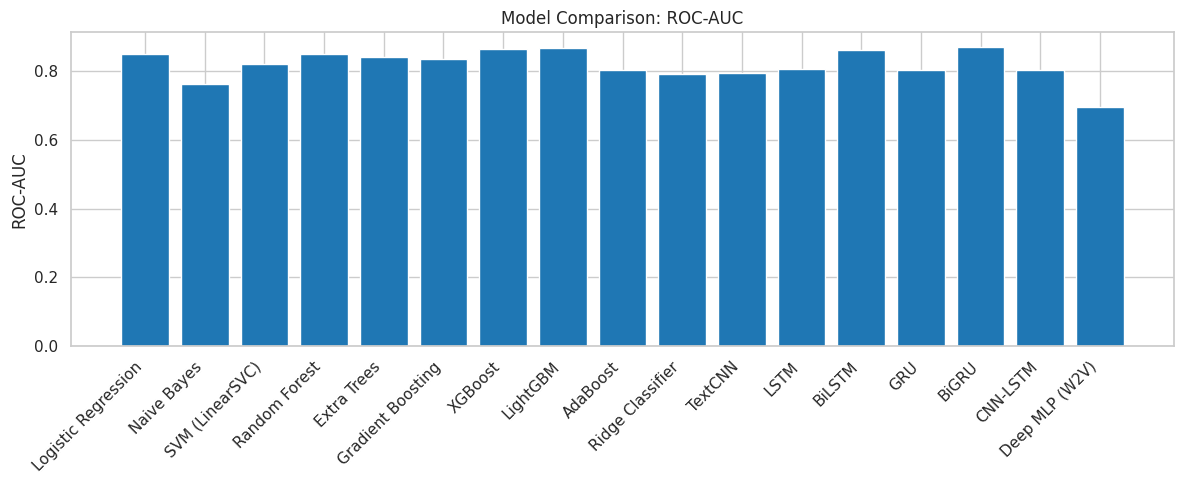

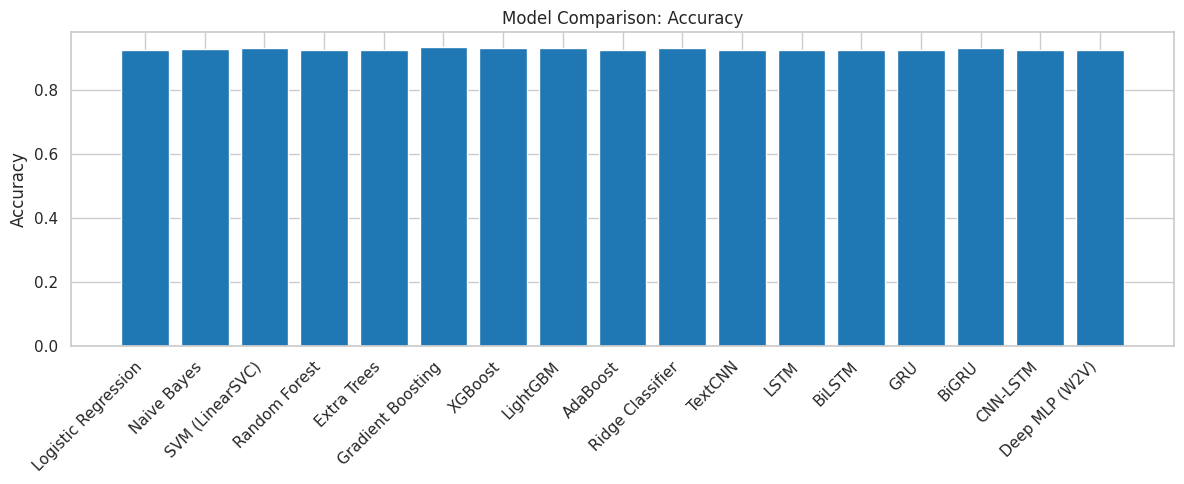

In [35]:
import matplotlib.pyplot as plt

'Metrics to plot'
metrics = ["F1-Score", "ROC-AUC", "Accuracy"]

'Iterate and create one figure per metric'
for m in metrics:
    plt.figure(figsize=(12,5))
    plt.bar(metrics_df.index, metrics_df[m], color="#1f77b4")
    plt.xticks(rotation=45, ha="right")  # rotate labels for readability
    plt.ylabel(m)
    plt.title(f"Model Comparison: {m}")
    plt.tight_layout()
    plt.show()

## 13. Feature Importance — Tree-Based Models

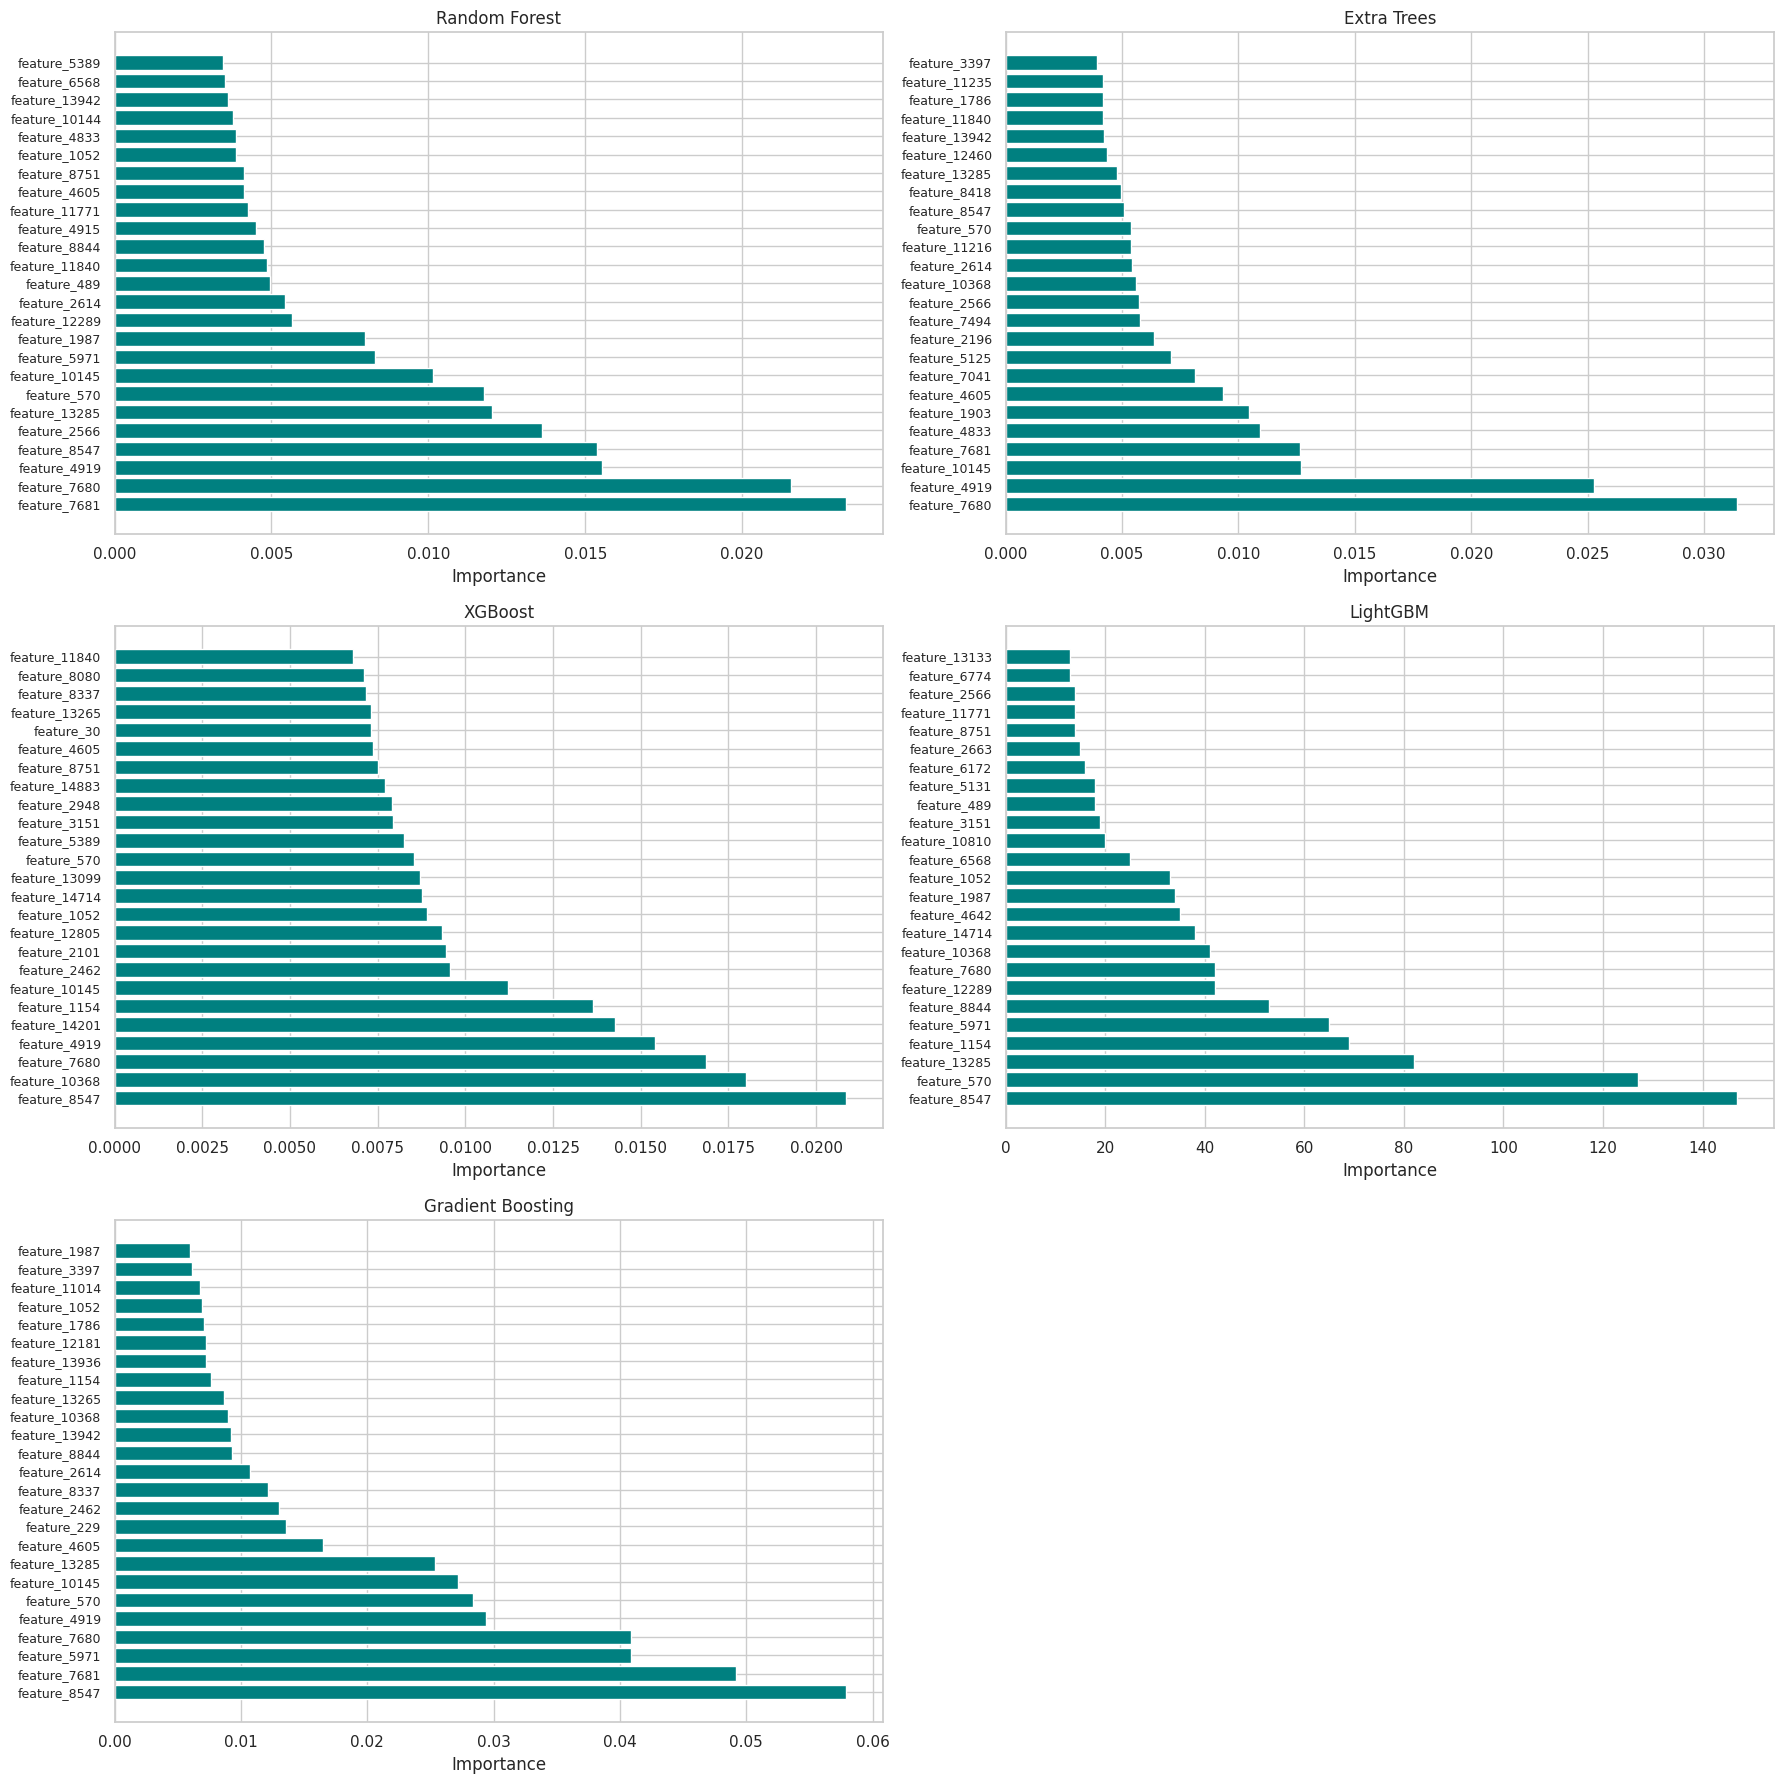

In [39]:
import matplotlib.pyplot as plt
import numpy as np

'Assign trained models from SK_MODELS'
rf_model   = SK_MODELS["Random Forest"]
et_model   = SK_MODELS["Extra Trees"]
gb_model   = SK_MODELS["Gradient Boosting"]
xgb_model  = SK_MODELS["XGBoost"]
lgbm_model = SK_MODELS["LightGBM"]

'Feature names: If Xtr_tf is a DataFrame', '#Attribute Error: If Xtr_tf is a NumPy array'
try:
    feature_names = Xtr_tf.columns
except AttributeError:
    feature_names = [f"feature_{i}" for i in range(Xtr_tf.shape[1])]

'Top features plotting function'
def plot_top_features(model, feature_names, title, ax):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-25:][::-1]  'top 25, most important on top'

    ax.barh(range(len(indices)), importances[indices], color="teal")
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([feature_names[i] for i in indices], fontsize=9)
    ax.set_xlabel("Importance")
    ax.set_title(title)

'Create subplots'
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

plot_top_features(rf_model, feature_names, "Random Forest", axes[0])
plot_top_features(et_model, feature_names, "Extra Trees", axes[1])
plot_top_features(xgb_model, feature_names, "XGBoost", axes[2])
plot_top_features(lgbm_model, feature_names, "LightGBM", axes[3])
plot_top_features(gb_model, feature_names, "Gradient Boosting", axes[4])

'Remove empty subplot'
axes[5].axis("off")

plt.tight_layout()
plt.show()

## 14. Final Summary & Rankings

In [40]:
print("=" * 65)
print("BEST BY EACH METRIC")
print("=" * 65)
for m in ["F1-Score","Accuracy","ROC-AUC","Precision","Recall"]:
    bm = metrics_df[m].idxmax()
    print(f"  {m:<14}: {bm:<28} ({metrics_df.loc[bm,m]:.4f})")
for m in ["RMSE","MSE","MAE"]:
    bm = metrics_df[m].idxmin()
    print(f"  {m:<14}: {bm:<28} ({metrics_df.loc[bm,m]:.4f})")

DL_NAMES = ["TextCNN","LSTM","BiLSTM","GRU","BiGRU","CNN-LSTM","Deep MLP (W2V)"]
ML_NAMES = [m for m in results.keys() if m not in DL_NAMES]
ml_f1 = metrics_df.loc[ML_NAMES,"F1-Score"].mean()
dl_f1 = metrics_df.loc[DL_NAMES,"F1-Score"].mean()
ml_auc = metrics_df.loc[ML_NAMES,"ROC-AUC"].mean()
dl_auc = metrics_df.loc[DL_NAMES,"ROC-AUC"].mean()
print(f"\n{'='*65}")
print(f"ML Models avg F1={ml_f1:.4f} | avg AUC={ml_auc:.4f}")
print(f"DL Models avg F1={dl_f1:.4f} | avg AUC={dl_auc:.4f}")
print(f"\n🥇 OVERALL BEST MODEL: {BEST}")
print("="*65)
for col in metrics_df.columns:
    print(f"  {col:<14}: {metrics_df.loc[BEST,col]:.4f}")

BEST BY EACH METRIC
  F1-Score      : Gradient Boosting            (0.9659)
  Accuracy      : Gradient Boosting            (0.9349)
  ROC-AUC       : BiGRU                        (0.8693)
  Precision     : BiGRU                        (0.9383)
  Recall        : Logistic Regression          (1.0000)
  RMSE          : Gradient Boosting            (0.2551)
  MSE           : Gradient Boosting            (0.0651)
  MAE           : Gradient Boosting            (0.0651)

ML Models avg F1=0.9637 | avg AUC=0.8284
DL Models avg F1=0.9618 | avg AUC=0.8049

🥇 OVERALL BEST MODEL: Gradient Boosting
  Accuracy      : 0.9349
  Precision     : 0.9367
  Recall        : 0.9971
  F1-Score      : 0.9659
  ROC-AUC       : 0.8360
  RMSE          : 0.2551
  MSE           : 0.0651
  MAE           : 0.0651
  R²            : 0.0564
  MAPE(%)       : 0.2914
